# Linguistic_analysis.ipynb

**Author:** Zane Zhang

**Date:** 2025/07/07 20:31

**Description:** 

This notebook is the linguistic analysis of engagement of depression misinformation.

First, we use a statistical t-test for comparisons, utilizing Welch's t-test to account for the imbalance of DMisinfo and non-DMisinfo posts. This step help us understand how engagement to DMisinfo and non-DMisinfo posts differ on Reddit. Relevant post-level metadata that we have previously retrieved includes the number of comments and scores.

Second, we adapt Linguistic Inquiry and Word Count (LIWC) analysis programme to understand who engages with DMisinfo posts on mental health and why.

In addition to LIWC, we use an unsupervised language modeling technique called the Sparse Additive Generative Model (SAGE) introduced by Eisenstein et al. (2011). We employ SAGE to identify discriminating n-grams (n = 1, 2, 3) between comments on DMisinfo and non-DMisinfo posts. The magnitude of the SAGE value of a linguistic token indicates the degree of its uniqueness to the distribution of comments on DMisinfo posts relative to the distribution of comments on non-DMisinfo posts. For each word, a positive SAGE value greater than 0 suggests that the n-gram is more representative of comments on DMisinfo posts, while a negative SAGE value suggests greater representativeness for comments on non-DMisinfo posts. We initialize the SAGE model using the 500 most frequent words (excluding stopwords and words shorter than 3 characters) for both DMisinfo and non-DMisinfo comments, with a baseline smoothing of 1.

**Note: This notebook is to run locally.**

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv("data/labeled_by_roberta_lstm.csv")
df = df[df['Total_comments'] >= 1]  # keep posts with more than 1 comment

# divide into 2 subset
df_misinfo = df[df['label_pred'] == 1]
df_nonmisinfo = df[df['label_pred'] == 0]

# difference of comments
t_comments = ttest_ind(df_misinfo['Total_comments'], df_nonmisinfo['Total_comments'], equal_var=False)

# difference of score
t_score = ttest_ind(df_misinfo['Score'], df_nonmisinfo['Score'], equal_var=False)

print(f"Welch's t-test for comments: t={t_comments.statistic:.3f}, p={t_comments.pvalue:.5f}")
print(f"Welch's t-test for score: t={t_score.statistic:.3f}, p={t_score.pvalue:.5f}")

Welch's t-test for comments: t=0.608, p=0.54397
Welch's t-test for score: t=-1.184, p=0.23708


We performed Welch's t-tests to compare user engagement (number of comments and post score) between DMisinfo and non-DMisinfo posts. The results revealed no no significant differences in either comments ($t=0.608, p=0.544$) or scores ($t=-1.184, p=0.237$). This suggests that misinformation posts on Reddit do not necessarily attract more or less engagement than accurate posts. However, engagement quantity does not fully capture engagement quality. We therefore proceed to linguistic analysis to better understand user motivation and sentiment in repsonding to DMisinfo posts.

Our analysis focuses on LIWC categories related to perceptions about depression, including language about affect, community, the body, religion, class, and gender. We remove all stopwords using the Natural Language Toolkit stopword list and normalize all counts by the length of the comment. We use Welch’s t-test to measure significant differences in lexicon usage across these relevant categories per platform, with False Discovery Rate (FDR) adjustment at a significance level of 0.05, denoted as the q-value.

**However, since LIWC is no longer open source for a single person, we purchased the LIWC-22 software to continue our research. Before we use the platform, we first merge the posts and comments. Then use the LIWC-22 software to calculate dimension values. Last we use python to do t-test and FDR correction.**

The next stage is batch processing and comparisons between groups. At first we merge the two dataset to get a comment file with post labels.

`comments_df.merge(...)` means merging the `comments_df` DataFrame **with** another DataFrame (`post_df`), which is called a **join operation**. 

`left_on='Post_id'` tells pandas to use `Post_id` column in `comments_df` as the key for the join. 

`right_on='Post_id'` tells pandas to use the `Post_id` column in `post_df` as the key for the join.

`how='inner'` specifies **the type of join**. `inner` means only rows that have matching keys in **both** DataFrames will be kept.

In [16]:
# Batch processing and comparisons between groups
# Import uid as an unique id for each comment
import pandas as pd

comments_df = pd.read_csv("data/comments_en.csv")
comments_df = comments_df.reset_index().rename(columns={"index": "uid"})
comments_df.to_csv("data/comments_with_uid.csv", index=False, encoding='utf-8')

# Merge the two dataset to get label
post_df = pd.read_csv("data/labeled_by_roberta_lstm.csv")
post_df = post_df[['Post_id', 'label_pred']]

merged_df = comments_df.merge(post_df, left_on='Post_id', right_on='Post_id', how='inner')
merged_df[['uid', 'Sentence_normalized', 'label_pred']].to_csv("data/comments_with_labels.csv", index=False, encoding='utf-8')

Then we move to the LIWC-22 platform for dimension value calculations. Since it easily breaks up when processing a large dataset, we split the whole comment file into batches and input respectively.

In [17]:
import os
import pandas as pd

df = pd.read_csv("data/comments_with_labels.csv")

chunk_size = 1000
output_dir = "data/liwc_batches"
os.makedirs(output_dir, exist_ok=True)

for i in range(0, len(df), chunk_size):
    chunk = df.iloc[i:i+chunk_size]
    out_path = os.path.join(output_dir, f"batch_{i//chunk_size + 1}.csv")
    chunk.to_csv(out_path, index=False, encoding="utf-8")

After completion of above, we start to combine all outputs and analyze the whole data.

In [2]:
# Combine outputs
import glob
import pandas as pd

# Match all batch output file paths
liwc_files = glob.glob("data/liwc_batches_results/LIWC-22*.csv")
# Read all files and stitches them into a DataFrame.
liwc_results = pd.concat([pd.read_csv(f) for f in liwc_files], ignore_index=True)

# Load original comments with labels
original = pd.read_csv("data/comments_with_uid.csv")[["uid", "Post_id"]]

# Merge with original data by uid
final_df = original.merge(liwc_results, on="uid", how="inner")

final_df.to_csv("data/liwc_combined.csv", index=False, encoding='utf-8')

In [ ]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 4.8 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 9.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 12.9 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 12.9 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 12.9 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.8 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---

In [ ]:
# Calculate Welch's t-test and FDR correction
import pandas as pd
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as smm
import numpy as np

df = pd.read_csv("data/liwc_combined.csv")

# Dimensions
liwc_cols = [
    'Drives',
    'affiliation',
    'achieve',
    'power',

    'Cognition',
    'allnone',
    'cogproc',
    'insight',
    'cause',
    'discrep',
    'tentat',
    'certitude',
    'differ',
    'memory',

    'Affect',
    'tone_pos',
    'tone_neg',
    'emotion',
    'emo_pos',
    'emo_neg',
    'emo_anx',
    'emo_anger',
    'emo_sad',
    'swear',

    'Social',
    'socbehav',
    'prosocial',
    'polite',
    'conflict',
    'moral',
    'comm',
    'socrefs',
    'family',
    'friend',
    'female',
    'male',

    'Lifestyle',
    'leisure',
    'home',
    'work',
    'money',
    'relig',
    
    'Physical',
    'health',
    'illness',
    'wellness',
    'mental',
    'substances',
    'sexual',
    'food',
    'death',

    'need',
    'want',
    'acquire',
    'lack',
    'fulfill',
    'fatigue',

    'reward',
    'risk',
    'curiosity',
    'allure',

    'Perception',
    'attention',
    'motion',
    'space',
    'visual',
    'auditory',
    'feeling'
]

# Division
df_mis = df[df['label_pred'] == 1]
df_non = df[df['label_pred'] == 0]

# Welch's t-test
results = []

for col in liwc_cols:
    tval, pval = ttest_ind(df_mis[col], df_non[col], equal_var=False)
    diff = df_mis[col].mean() - df_non[col].mean()
    cohens_d = diff / np.sqrt((df_mis[col].var() + df_non[col].var()) / 2)
    results.append((col, df_mis[col].mean(), df_non[col].mean(), diff, pval, cohens_d))
    
# FDR correction
pvals = [r[4] for r in results]
rejects, qvals, *_ = smm.multipletests(pvals, alpha=0.05, method='fdr_bh')

# Output
final_results = pd.DataFrame(results, columns=['Category', 'Mean_DM', 'Mean_NonDM', 'Diff', 'p', 'Cohen_d'])
final_results['q'] = qvals
final_results['sig'] = rejects

def get_stars(q):
    if q <= 0.001:
        return '***'
    elif q <= 0.01:
        return '**'
    elif q <= 0.05:
        return '*'
    else:
        return ''
final_results['stars'] = final_results['q'].apply(get_stars)

final_results.to_csv("reports/liwc_comparison_results.csv", index=False, encoding='utf-8')

The next stage is to conduct SAGE analysis. At first, we initialize the SAGE model using the 500 most frequent words (excluding stopwords and words shorter than 3 characters) for both DMisinfo and non_DMisinfo comments, with a baseline smoothing of 1.

In [1]:
# Initialization
import nltk
from nltk.corpus import stopwords
import pandas as pd
import re

nltk.download("stopwords")

comments_df = pd.read_csv("data/comments_with_labels.csv")

# Filter only comments with at least 3 characters
def clean_comment(text):
    tokens = re.findall(r"\b\w{3,}\b", text.lower())
    stops = set(stopwords.words("english"))
    return " ".join([t for t in tokens if t not in stops])

comments_df["cleaned"] = comments_df["Sentence_normalized"].apply(clean_comment)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zane\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Vectorize using n-grams
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=500, binary=False)
x = vectorizer.fit_transform(comments_df["cleaned"])
y = comments_df["label_pred"]

In [3]:
# Fit sparse logistic regression (SAGE approximation)
import numpy as np
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')   # C=1 is smoothing
clf.fit(x, y)

# Extract coefficients
feature_names = np.array(vectorizer.get_feature_names_out())
coef = clf.coef_[0]

# Sort by discriminative weight
sage_df = pd.DataFrame({
    "n-gram": feature_names,
    "SAGE": coef
})
sage_df = sage_df.sort_values("SAGE", ascending=False)

In [4]:
# Save and interpret top results
# Top n-grams for DMisinfo
sage_df.head(25).to_csv("reports/top_ngrams_DMisinfo.csv", index=False, encoding='utf-8')
# Top n-grams for non-DMisinfo
sage_df.tail(25).sort_values("SAGE", ascending=True).to_csv("reports/top_ngrams_nonDMisinfo.csv", index=False, encoding='utf-8')

<Figure size 1000x600 with 0 Axes>

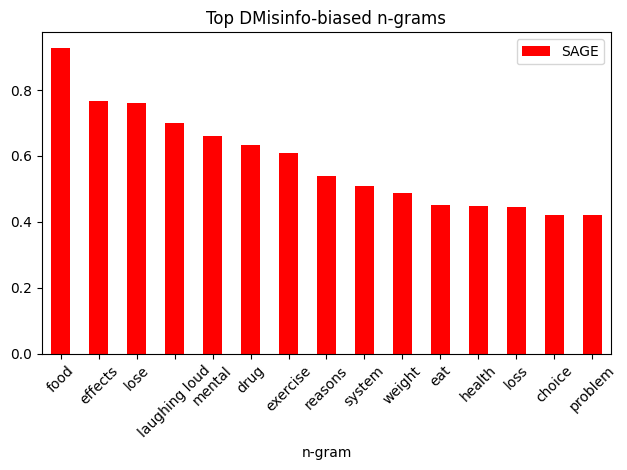

<Figure size 1000x600 with 0 Axes>

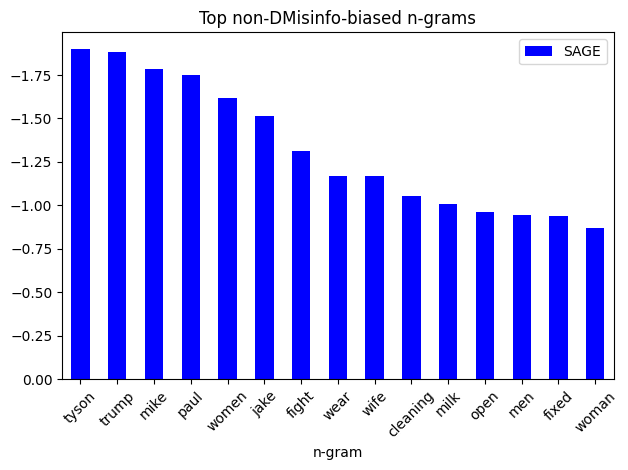

In [5]:
# Optional: visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sage_df.head(15).plot.bar(x="n-gram", y="SAGE", title="Top DMisinfo-biased n-grams", color="red")
plt.xticks(rotation=45)     # Rotate 45°
plt.tight_layout()
plt.savefig("reports/sage_top_DMisinfo.png")

plt.figure(figsize=(10, 6))
sage_df.tail(15).sort_values("SAGE", ascending=True).plot.bar(x="n-gram", y="SAGE", title="Top non-DMisinfo-biased n-grams", color="blue").invert_yaxis()   # invert the vertical coordinate
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/sage_top_nonDMisinfo.png")